[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-gcs/access_gcs.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-gcs/access__gcs.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-gcs/access__gcs.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-gcs/access__gcs.ipynb

>📘 Learning Objectives
>
> 1. Access a file on Google Cloud Storage (GCS)
> 3. Plot it.
> 4. Access when authentication is needed.

## Access a public file

You need to know the bucket url and prefix that with `gcs`.

In [12]:
# first suppress noisy warnings
import warnings
import re

# Suppress the specific GCP user credential quota project warning
warnings.filterwarnings(
    "ignore",
    message="Your application has authenticated using end user credentials from Google Cloud SDK without a quota project.",
    category=UserWarning,
    module="google.auth._default"
)

In [13]:
import xarray as xr
import fsspec
url = "gcs://nmfs_odp_nwfsc/CB/nwm_daily_means/wr1718/streamflow/netcdf/daily_mean_2018.nc"
fs = fsspec.filesystem("gcs", anon=True)
f = fs.open(url, mode="rb")
ds = xr.open_dataset(f)

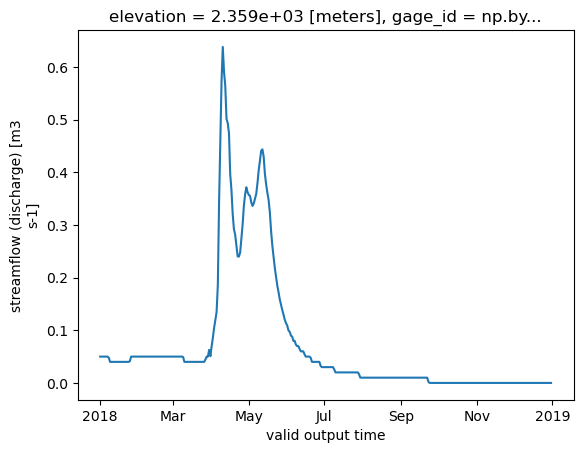

In [7]:
# Plot
ds["streamflow"].isel(feature_id=1).plot();

In [3]:
# close the file when done
f.close()

## Accessing a private bucket

Run the following from the terminal. This will save your authentication key to 
```
~/.config/gcloud/application_default_credentials.json
```

In [9]:
# Now import fsspec
import xarray as xr

# Use authenticated GCS access (anon=False)
fs = fsspec.filesystem("gcs", anon=False)

# Path to the private object in GCS
url = "gcs://nmfs_odp_nwfsc/CB/nwm_daily_means/wr1718/streamflow/netcdf/daily_mean_2018.nc"

# Open and read with xarray
with fs.open(url, mode="rb") as f:
    ds = xr.open_dataset(f)


/srv/conda/envs/notebook/lib/python3.12/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
